# Project: Reimplementation and Improvement of the RLT Algorithm (Reinforcement Learning Trees)

**Goal:** This notebook structures the project for reimplementing the RLT algorithm in Python.

**Authors:** Kousay Najar, Hamza Farhani, Taoufik Krid, Wiem Ben M’Sahel, Rawen Mezzi, Mohamed Khayat

**Date:** 11/2025

## Phase 1: Business Understanding

This phase aims to define the objectives from a business perspective and translate them into a well-defined data science problem.

# Problem statement & Study of Existing Methods and Limitations & Defining Strategy

### 1. Problem Statement

#### Context and Motivation
The problem addresses high-dimensional sparse settings where traditional tree-based methods like Random Forests show limitations. In scenarios with $p$ variables, only $p_1 \ll p$ strong variables carry the true signal, while $p_2 = p - p_1$ are noise variables.

#### Key Challenges Identified
**Random Feature Selection Limitations:** In high-dimensional settings with many noise variables, random feature selection provides little opportunity to consider strong variables as splitting rules. When $p$ is large and $p_1$ is small, the probability of selecting a strong variable decreases dramatically.

**Terminal Node Degradation:** As sample size decreases toward terminal nodes, identifying important variables becomes increasingly difficult regardless of the model used. This causes splitting variable selection to behave almost randomly, leading to performance similar to purely random forests.

**Hidden Structures:** Marginal comparisons of splitting variables can fail to identify strong variables, especially with structures like the checkerboard pattern where variables show little marginal effect but strong joint effects.

#### Research Objectives
Develop a tree-based method that achieves consistency with convergence rates depending only on $p_1$ (number of strong variables) rather than $p$ (total number of variables). The method should force splits to concentrate on strong variables throughout the tree construction, especially toward terminal nodes.

### 2. Study of Existing Methods and Limitations

#### Traditional Random Forests
**Strengths:** State-of-the-art ensemble method with flexible non-parametric structure and capacity for handling high-dimensional data. Shows great potential in cancer studies with large numbers of genes or SNPs.

**Limitations:**
- Unsatisfactory performance in some studies compared to other machine learning tools
- Random feature selection creates bias in variable importance measures when using small numbers of features
- Using large numbers of predictors causes overfitting toward terminal nodes where sample size is small
- Lack of theoretical attention on sparsity for tree-based methods

#### Alternative Tree-Based Methods
- **Extremely Randomized Trees (ET):** Use random cut points rather than searching for best cut points, achieving similar performance to Random Forests at reduced computational cost.
- **Bayesian Additive Regression Trees (BART):** Integrate tree-based methods into a Bayesian framework.
- **Purely Random Forests:** Provide friendly framework for theoretical analysis but are extremely inefficient because most splits select noise variables, especially in sparse settings.

#### Linear Models
- **Lasso and Penalized Methods:** Among the most popular methods for identifying signal variables in linear models. However, they cannot capture complex non-linear and interaction effects that tree-based methods can handle.

#### Theoretical Gaps
- **Consistency Issues:** The asymptotic behavior of random forests relies heavily on the particular splitting rule implemented. Some greedy construction rules demonstrate inconsistency under certain conditions.
- **No Method with Both Properties:** Up to now, there appears to be no tree-based method possessing both established theoretical validity and excellent practical performance.

### 3. Defining Strategy

#### Three-Fold Innovation Approach

**1. Reinforcement Learning for Splitting (The "Look-Ahead")**
*   **Concept:** Instead of greedily choosing the split with the best *immediate* result (like standard Random Forests), RLT looks ahead.
*   **How:** It runs a small internal model (embedded model) at every node to calculate Variable Importance. It chooses variables that offer the best *future* rewards, allowing it to detect hidden patterns (like checkerboards) that standard trees miss.

**2. Progressive Variable Muting (The "Noise Filter")**
*   **Concept:** As the tree grows deeper and data becomes scarcer, the risk of splitting on noise increases.
*   **How:** RLT progressively "mutes" (discards) weak variables at each level. This forces deep nodes to split only on strong, proven signals, ensuring the model remains robust even with small sample sizes.

**3. Linear Combination Splits (The "Smarter Cut")**
*   **Concept:** Standard trees only cut horizontally or vertically (e.g., $X_1 > 5$).
*   **How:** RLT can split on a weighted combination of top variables (e.g., $0.5X_1 + 0.3X_2 > 0$). The weights are determined by the Variable Importance calculated in step 1, allowing the tree to capture local linear trends efficiently.

#### Theoretical & Validation Basis
*   **Theory:** The model is mathematically proven to converge based on the number of *strong* variables, effectively ignoring the total number of noise variables.
*   **Validation:** We validate this approach using:
    *   **4 Simulated Scenarios:** Testing linear, non-linear, and highly correlated relationships.
    *   **10 Real-World Datasets:** Benchmarking against Random Forests, Gradient Boosting, and Lasso on standard UCI datasets.

### 1.1 Business Objectives (BOs)
The BOs describe the expected value from a non-technical perspective.

- **BO1: Reimplement the strategy.** Define the strategy (RLT).  
- **BO2: Compare classical solutions with our solution.**  
- **BO3: Make the strategy's decisions explainable.**  
- **BO4: Optimize the strategy.**  

### 1.2 Data Science Objectives (DSOs)
DSOs are the technical goals that, once achieved, will fulfill the business objectives.

- **DSO1: Implement the Reinforcement Learning Trees (RLT) algorithm.**  
- **DSO2: Conduct a comparative study between the RLT model and classical methods.**  
- **DSO3: Explain the model's predictions using XAI techniques.**  
- **DSO4: Optimize the RLT model.**  


## Phase 2 : Data Understanding

We will analyze each dataset separately to understand their characteristics, distributions, and quality.


🔍 ANALYSE DU DATASET : BREAST_CANCER



Number of Rows is : 569


Number of Columns is : 33


Qualitatives Columns are : 

None

Quantatatives Columns are : 
radius_mean
texture_mean
perimeter_mean
area_mean
smoothness_mean
compactness_mean
concavity_mean
concave points_mean
symmetry_mean
fractal_dimension_mean
radius_se
texture_se
perimeter_se
area_se
smoothness_se
compactness_se
concavity_se
concave points_se
symmetry_se
fractal_dimension_se
radius_worst
texture_worst
perimeter_worst
area_worst
smoothness_worst
compactness_worst
concavity_worst
concave points_worst
symmetry_worst
fractal_dimension_worst
Unnamed: 32

The Target is : diagnosis (Type: Categorical)

Unnamed: 32 : 100.00 % missing values

No duplicated values


Outliers detected in the following 29 features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'pe

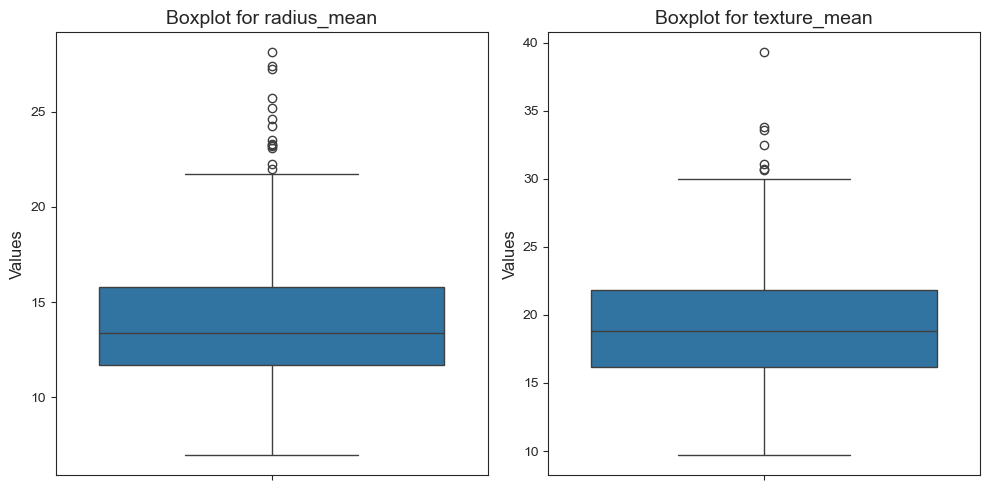

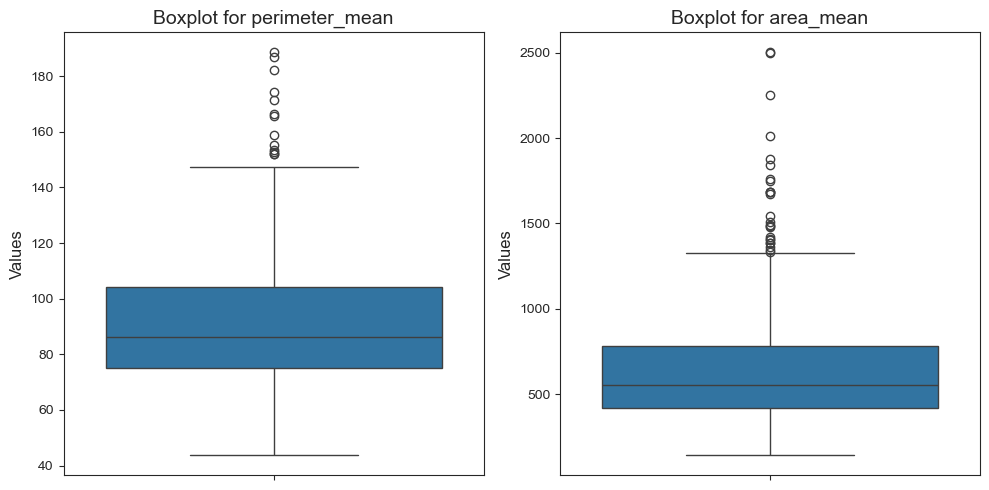

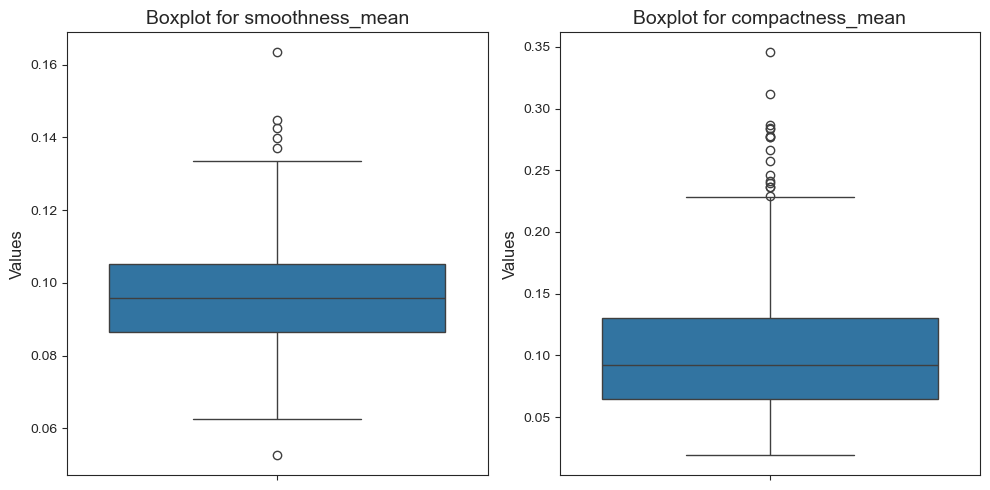

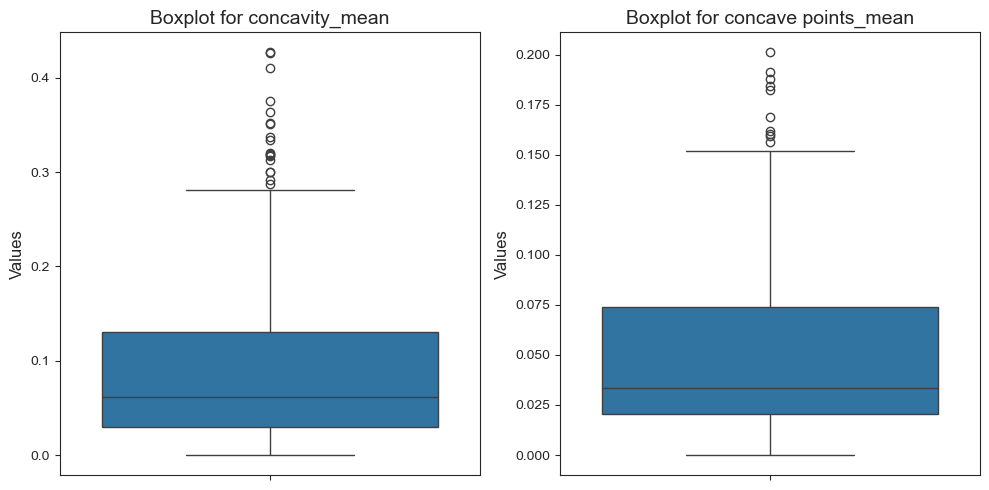

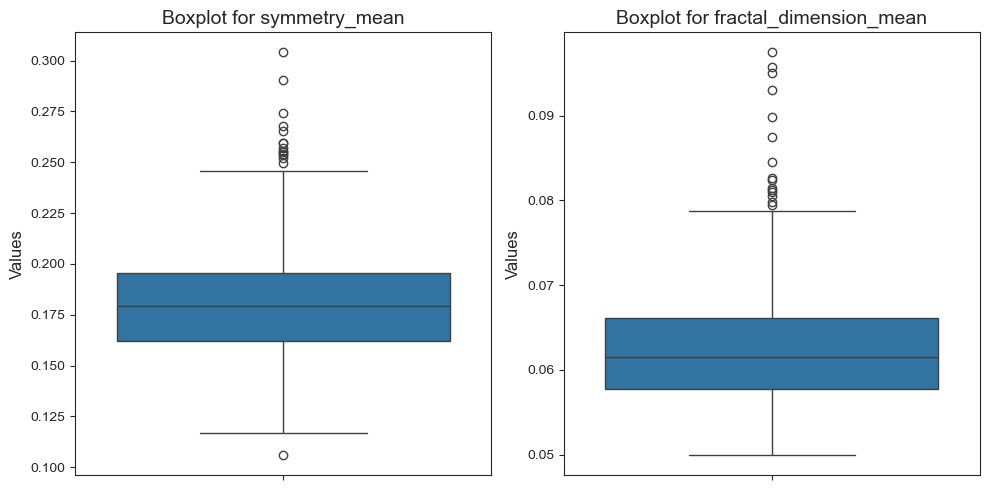


Histplots for features (First 5)



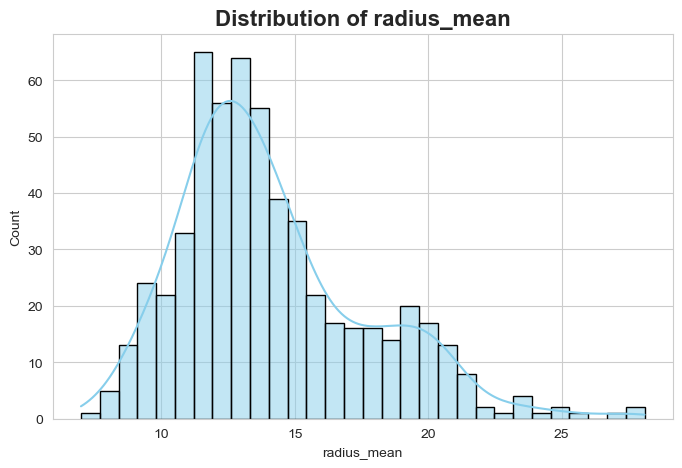

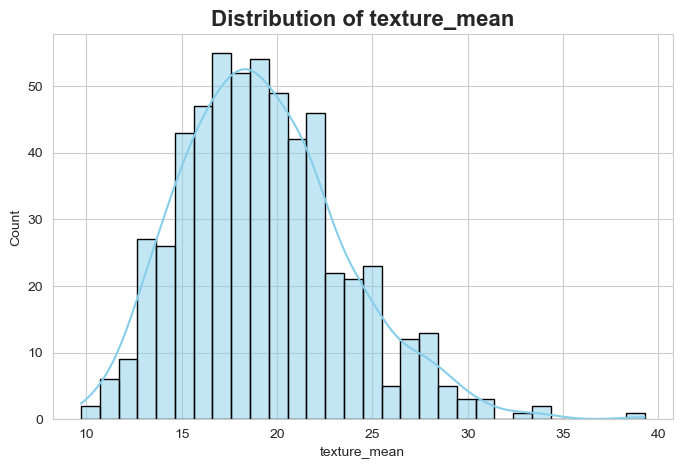

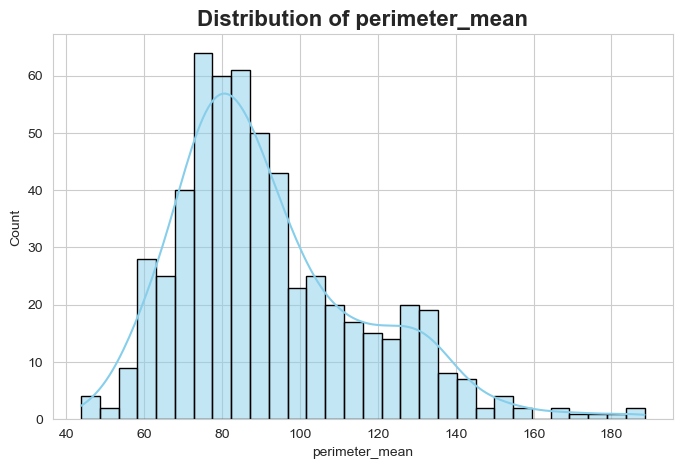

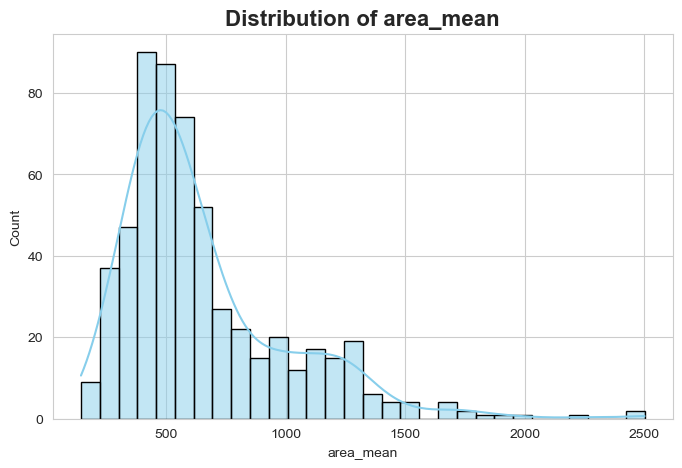

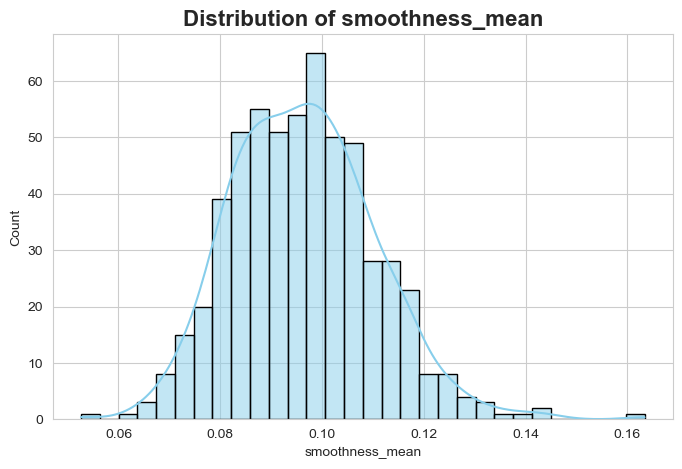


Countplot for Target



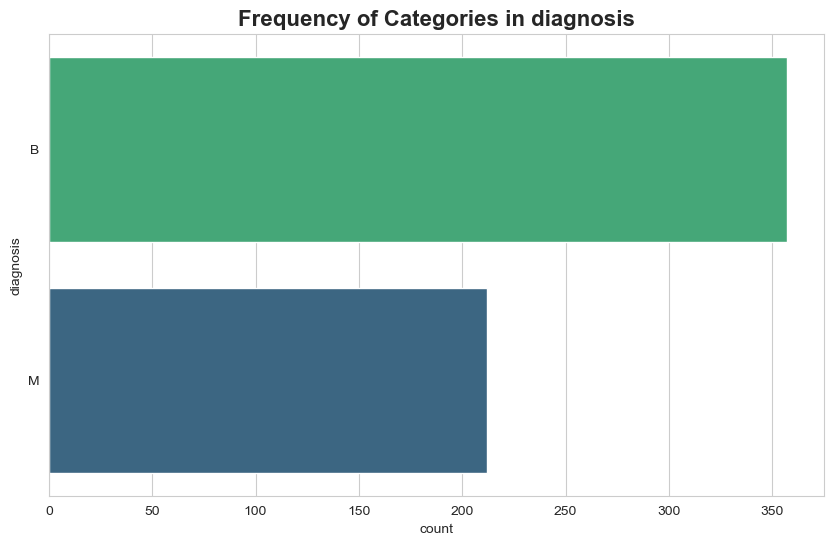

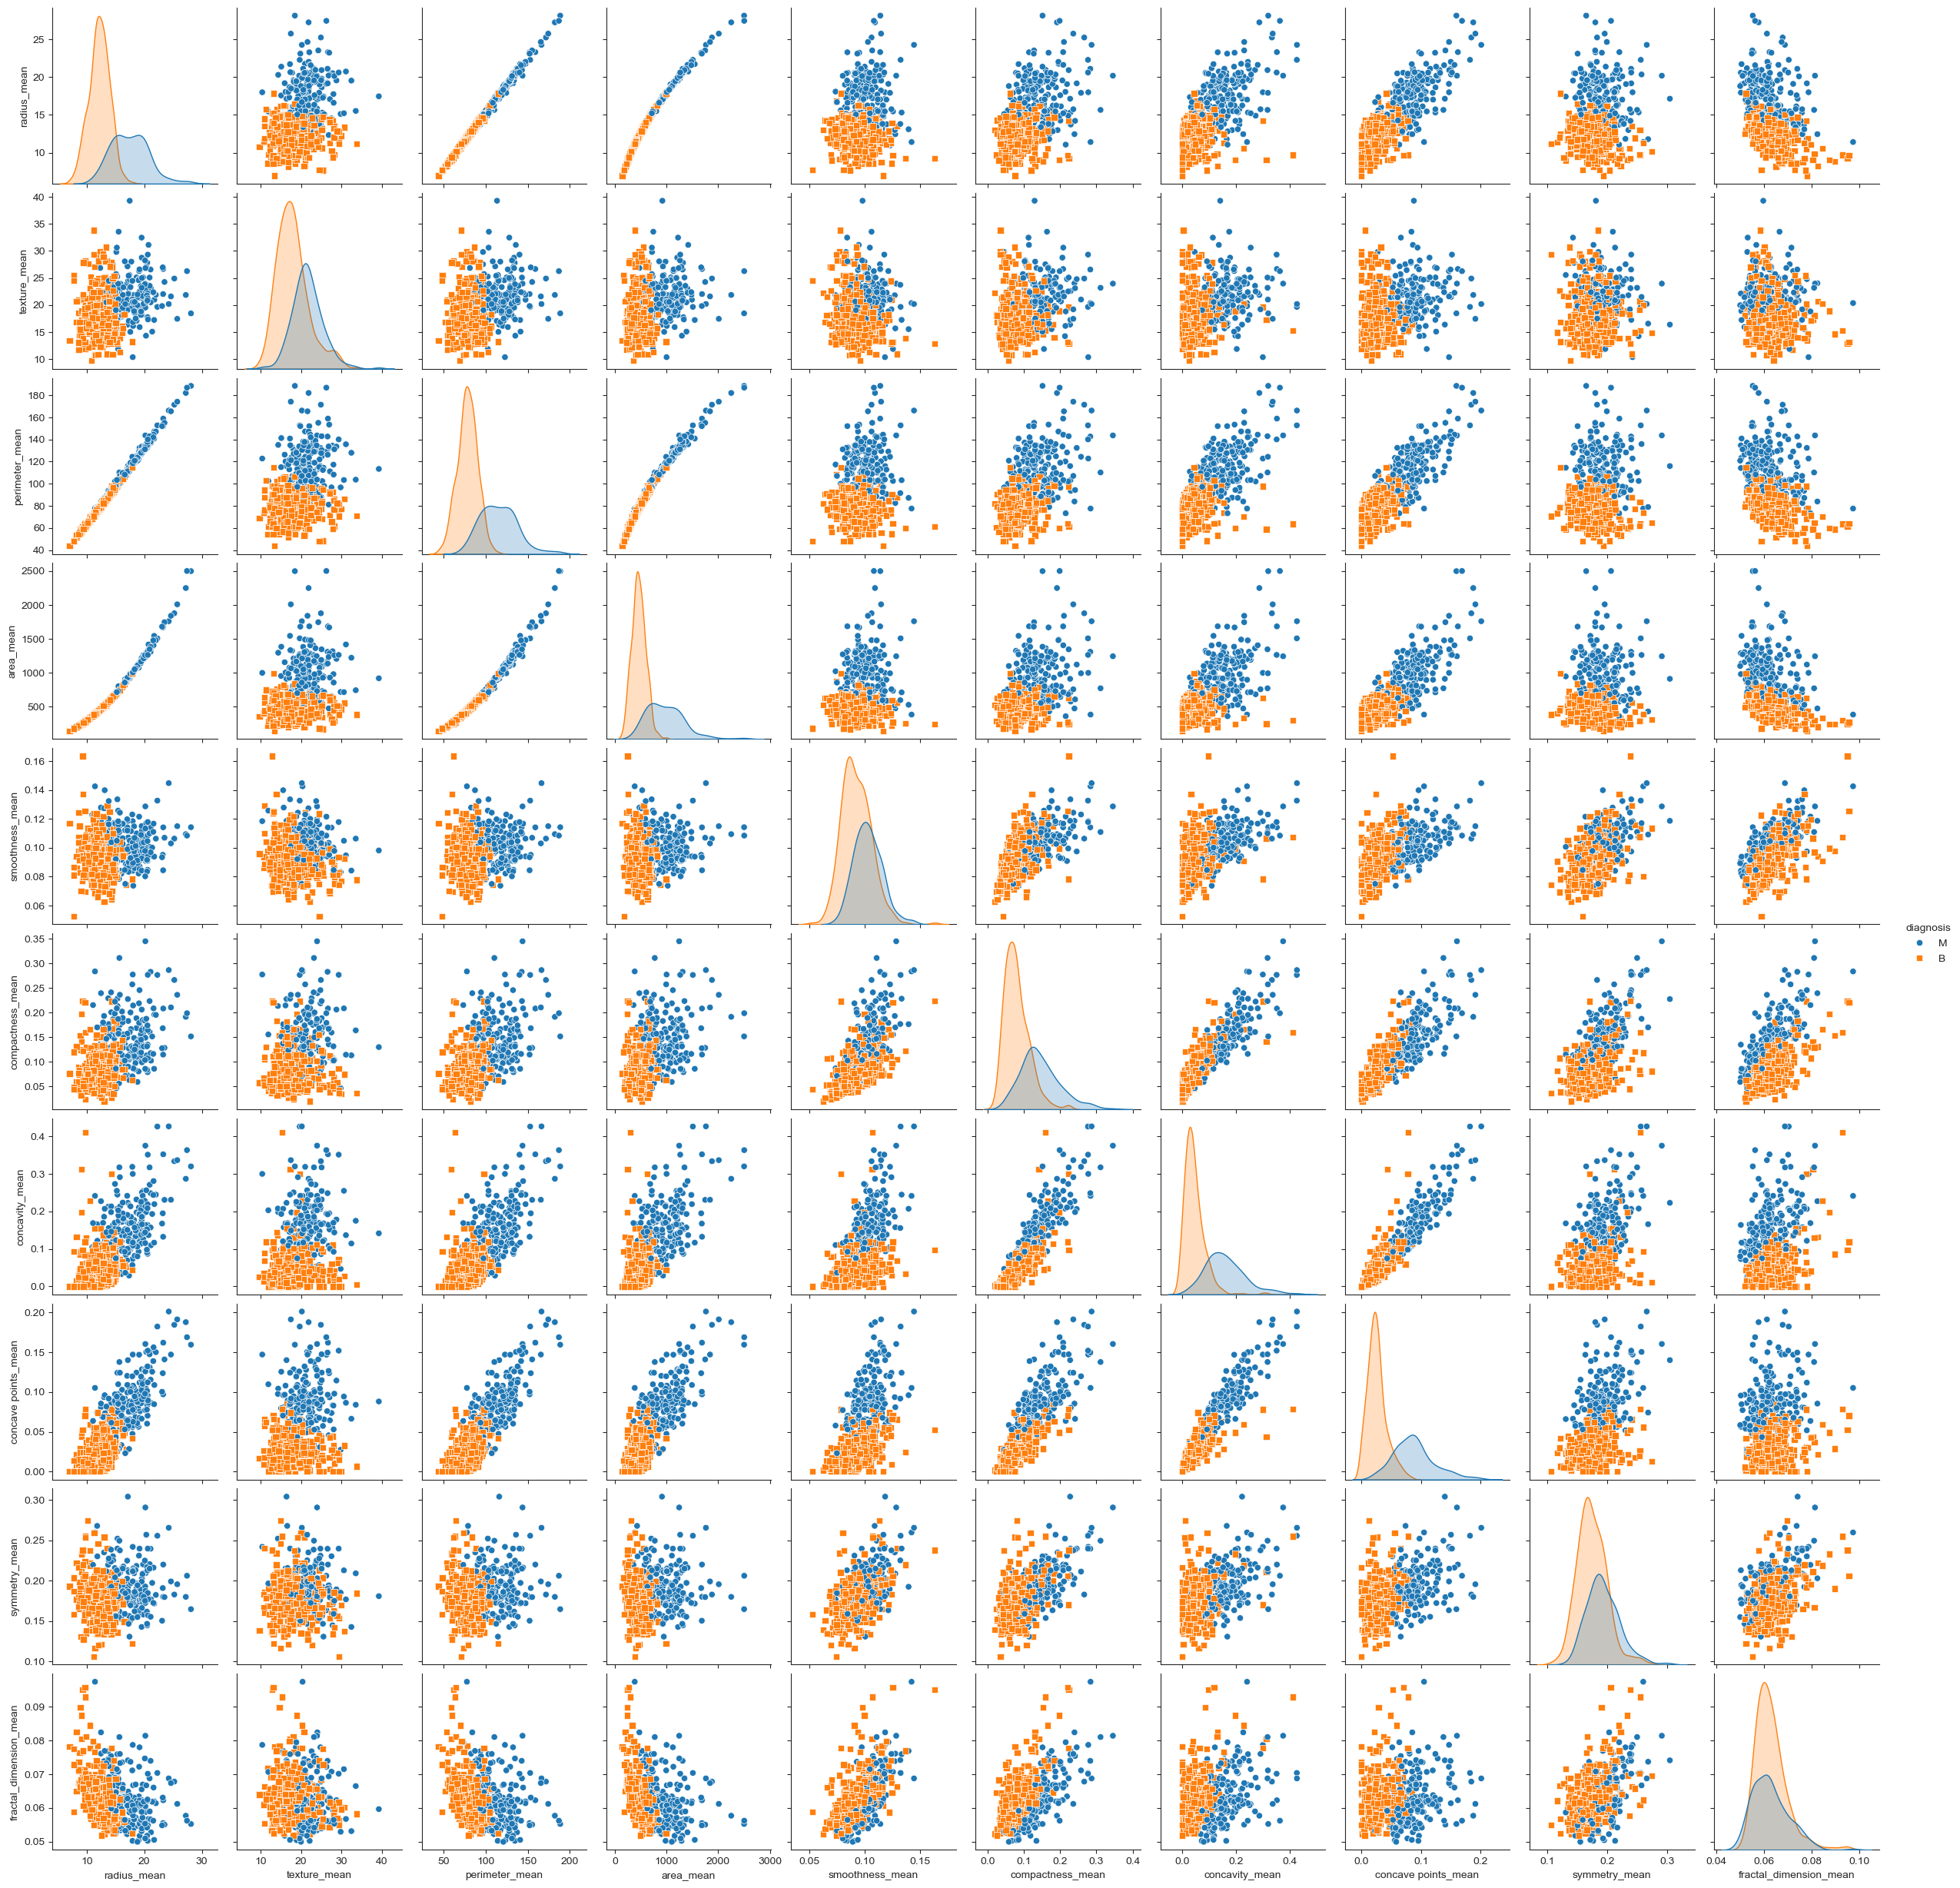


🔍 ANALYSE DU DATASET : CONCRETE



Number of Rows is : 1005


Number of Columns is : 9


Qualitatives Columns are : 

None

Quantatatives Columns are : 
Cement
Blast Furnace Slag
Fly Ash
Water
Superplasticizer
Coarse Aggregate
Fine Aggregate
Age

The Target is : Strength (Type: Continuous)


No missing values


No duplicated values


Outliers detected in the following 5 features: ['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate', 'Age']


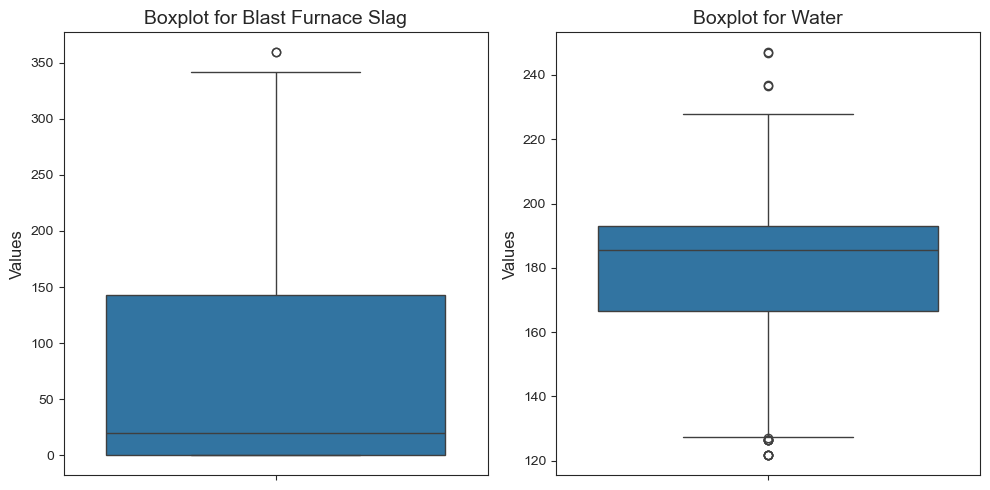

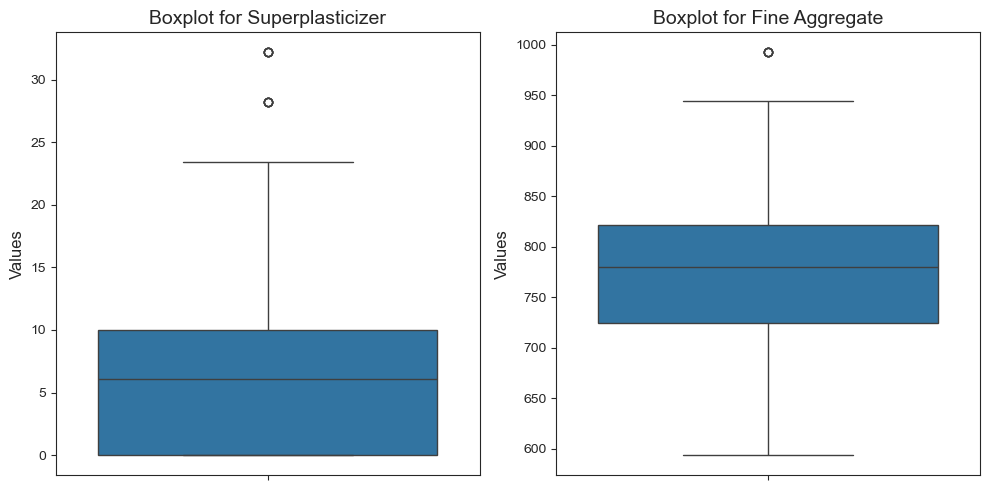

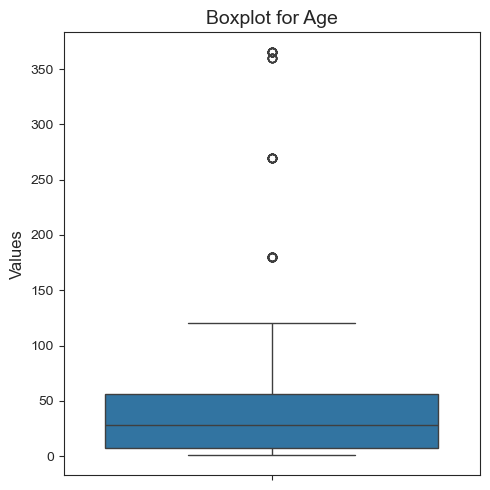


Histplots for features (First 5)



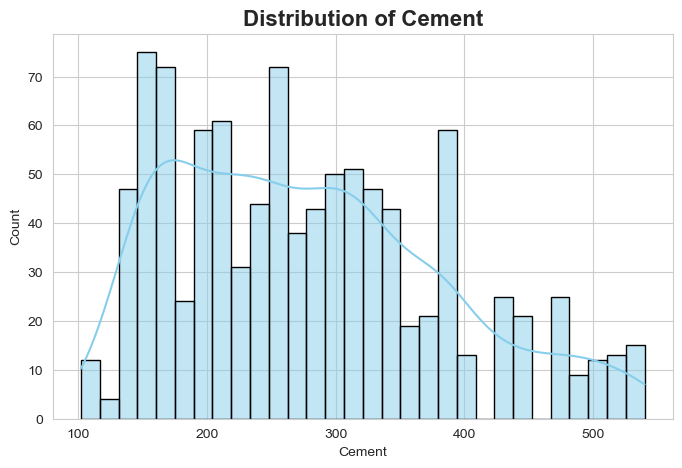

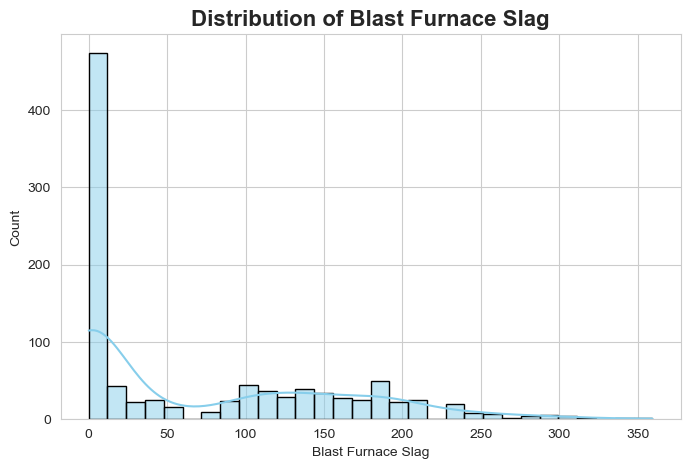

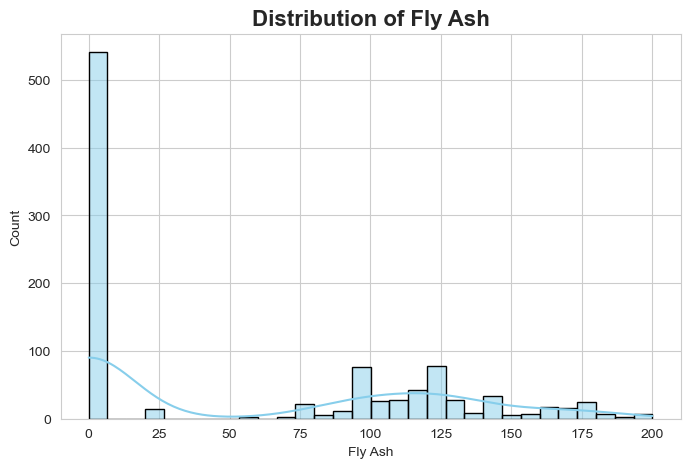

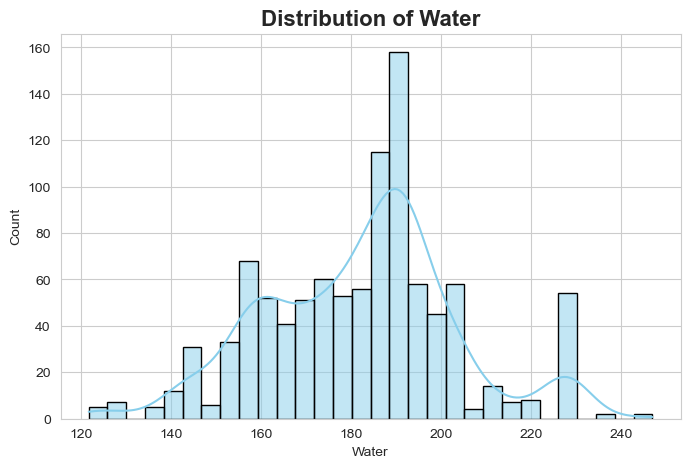

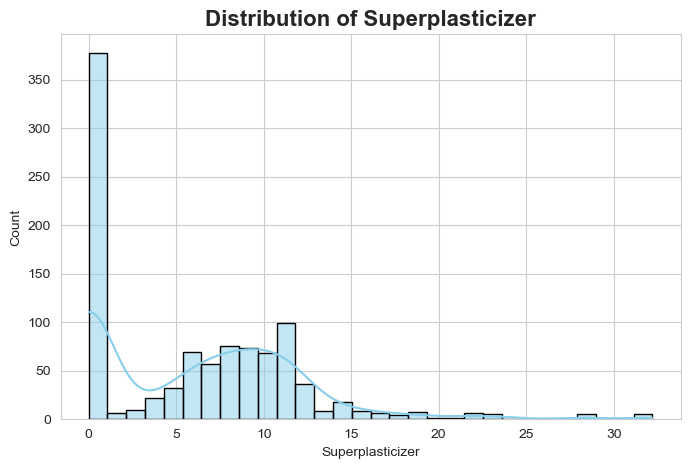


Histplot for Target



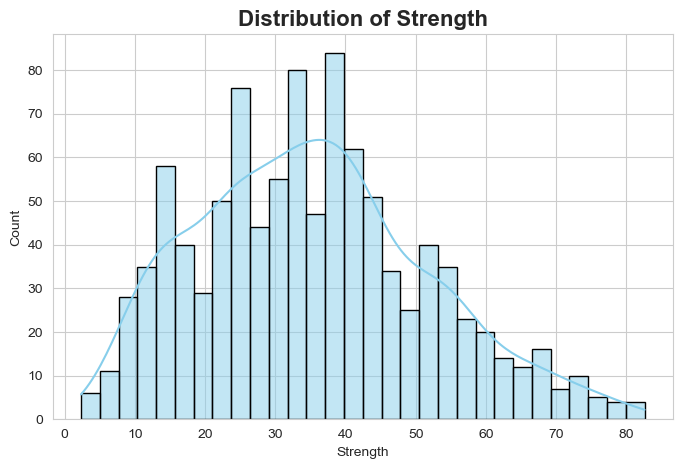

KeyboardInterrupt: 

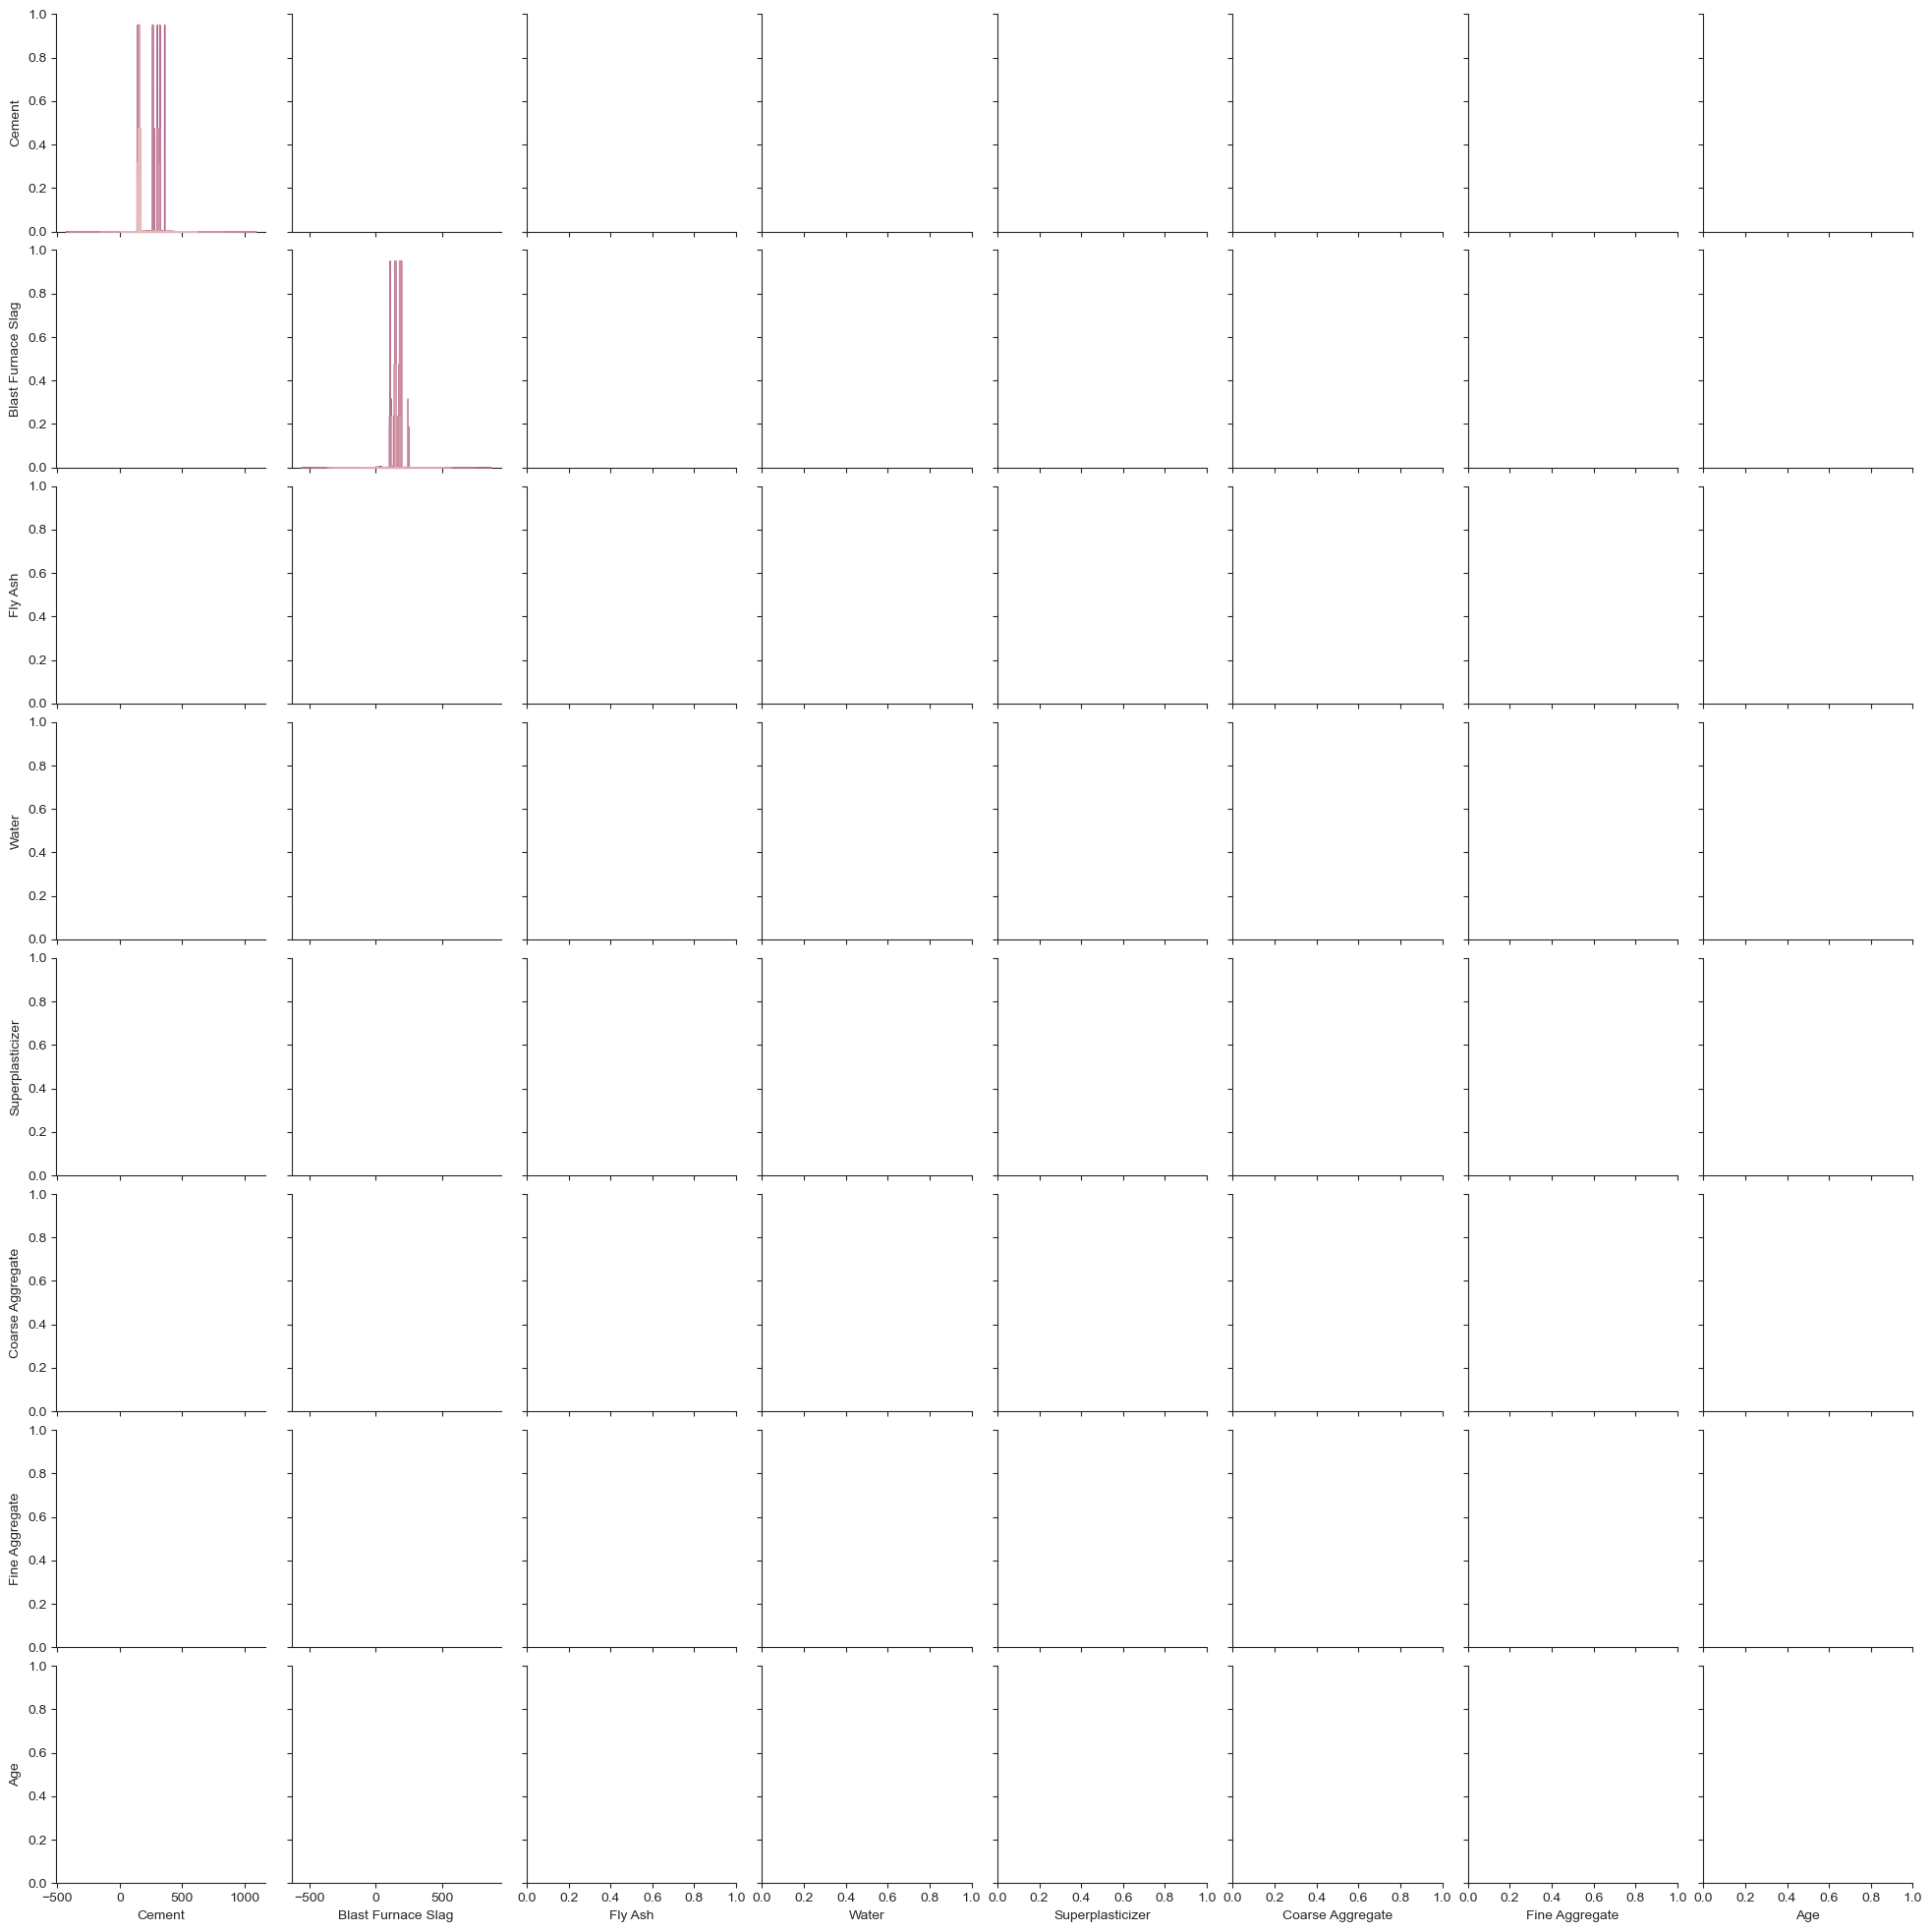

In [ ]:
from src.scripts import data_understanding as data_understanding
import importlib
from src.utils import dataset_wrapper

importlib.reload(data_understanding)
importlib.reload(dataset_wrapper)

for dataset_name in dataset_wrapper.datasets_dict.keys():
    print("\n" + "=" * 100)
    print(f"🔍 ANALYSE DU DATASET : {dataset_name.upper()}")
    print("=" * 100 + "\n")
    wrapped_ds = dataset_wrapper.DatasetWrapper(dataset_name)
    data_understanding.understand_data(wrapped_ds)

## Phase 3 : Préparation des Données (Data Preparation)

La préparation consistera principalement à diviser nos jeux de données synthétiques.

In [ ]:
import src.scripts.data_preparation as data_preparation

importlib.reload(data_preparation)
importlib.reload(dataset_wrapper)


for dataset_name in dataset_wrapper.datasets_dict.keys():
    wrapped_ds = dataset_wrapper.DatasetWrapper(dataset_name)
    _ = data_preparation.prepare_data(wrapped_ds)

Shape of X_train: (455, 30)
Shape of X_test: (114, 30)
Shape of y_train: (455,)
Shape of y_test: (114,)
Shape of X_train: (804, 8)
Shape of X_test: (201, 8)
Shape of y_train: (804,)
Shape of y_test: (201,)
Shape of X_train: (156, 22)
Shape of X_test: (39, 22)
Shape of y_train: (156,)
Shape of y_test: (39,)
Shape of X_train: (166, 60)
Shape of X_test: (42, 60)
Shape of y_train: (166,)
Shape of y_test: (42,)
Shape of X_train: (1087, 11)
Shape of X_test: (272, 11)
Shape of y_train: (1087,)
Shape of y_test: (272,)
Shape of X_train: (318, 7)
Shape of X_test: (80, 7)
Shape of y_train: (318,)
Shape of y_test: (80,)
Shape of X_train: (391, 3)
Shape of X_test: (98, 3)
Shape of y_train: (391,)
Shape of y_test: (98,)


## Phase 4: Modeling

This phase is the core of the project. We implement RLT and add the extensions required by DSO2 (varied embedded models) and DSO3 (explainability).

### DSO1: Re-implementing the Strategy (RLT)

**Objective:** To build and validate the RLT model by reproducing the paper's experiments on the four controlled, simulated scenarios.

| Model | Dataset(s) for Development | Variables Involved | Key Parameters / Hyperparameters to Implement |
| :--- | :--- | :--- | :--- |
| **RLT (Reinforcement Learning Trees)** | **Simulated Scenarios 1-4** | **Data is programmatically generated for each scenario:**<br>- **Scenario 1 (Classification):** Signal from `X(1)` & `X(2)`; other `p-2` variables are independent noise.<br>- **Scenario 2 (Non-linear):** Non-linear signal from `X(1)` & `X(2)`; other `p-2` variables are independent noise.<br>- **Scenario 3 (Correlated):** Interaction signal from `X(50)`, `X(100)`, `X(150)`, `X(200)`; other variables are strongly correlated noise.<br>- **Scenario 4 (Linear):** Linear signal from `X(50)`, `X(100)`, `X(150)`; other variables are correlated noise.<br><br>*For all scenarios, total dimension `p` is tested at 200, 500, and 1000.* | - `M` (number of trees) = 100<br>- `nmin` = n^(¹/³)<br>- **Embedded model logic** (Extremely Randomized Trees)<br>- **Muting mechanism** (0%, 50%, 80%)<br>- **Linear combination `k` mechanism** (for k=1, 2, 5) |

### DSO2: Comparing Classical Solutions with Our Solution

**Objective:** To conduct a rigorous benchmark on all 10 real-world datasets, comparing the performance and computational efficiency of the re-implemented RLT against standard, high-performing tree-based models.

| Model | Dataset(s) for Comparison | Variables Involved | Hyperparameter Search Space | Execution Time |
| :--- | :--- | :--- | :--- | :--- |
| **RLT (Our Solution)** | **All 10 real datasets** | **For each dataset:**<br>1. Select numeric features only.<br>2. Standardize them (mean=0, var=1).<br>3. Add noisy covariates to reach a total of **p=500** features. | - `k` (linear combination size) in<br>- `muting_rate` in [0, 0.5, 0.8]<br>- `nmin` set to n¹/³ | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|
| **Random Forests (RF)** | All 10 real datasets | *Identical data pipeline as RLT* | - `ntrees` in<br>- `mtry` (features per split) in [√p, p/3, p]<br>- `nodesize` (min leaf size) in [2, n¹/³] | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|
| **Gradient Boosting (GBM)** | All 10 real datasets | *Identical data pipeline as RLT* | - `ntrees` (boosting rounds) in (use early stopping)<br>- `learning_rate` in [0.01, 0.05, 0.1]<br>- `interaction.depth` in<br>- `n.minobsinnode` in [5, 10, n¹/³] | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|
| **XGBoost** | All 10 real datasets | *Identical data pipeline as RLT* | - `n_estimators` in (use early stopping)<br>- `learning_rate` in [0.01, 0.05, 0.1]<br>- `max_depth` in<br>- `subsample` in [0.7, 0.8, 0.9]<br>- `colsample_bytree` in [0.7, 0.8, 0.9] | **Measure and compare:**<br>1. Total training time.<br>2. Prediction time on the test set.<br>|

### DSO3: Making the Strategy's Decisions Explainable

**Objective:** To diagnose and understand the behavior of the RLT model by applying global and local explainability techniques, and comparing its decision-making process to that of a standard Random Forest.

| Model | Explainability Technique | Dataset(s) for Explainability | Goal of the Technique |
| :--- | :--- | :--- | :--- |
| **RLT** & **Random Forest (RF)** | **Global Feature Importance (VIM)** | **Choose 2 contrasting datasets:**<br>1. Where RLT excelled (e.g., `concrete`).<br>2. Where RLT was less dominant (e.g., `Boston housing`). | To identify which of the 500 features the model considers most predictive *overall*, across the entire dataset. |
| **RLT** | **LIME (Local Explanations)** | Same two datasets. | To explain *why the model made a specific prediction for a single instance (row)*, providing local, case-by-case insight. |

### DSO4: Proposing and Testing Our Own Improvement

**Objective:** To validate if our proposed modifications to the RLT algorithm yield a statistically significant improvement in performance or efficiency over the original implementation.

| Model | Dataset(s) for Testing | Variables Involved | Key Parameters / Hyperparameters to Test |
| :--- | :--- | :--- | :--- |
| **RLT (Baseline)** | **All 10 real datasets** | **Identical pipeline for both models:**<br>1. Select numeric features only.<br>2. Standardize them (mean=0, var=1).<br>3. Add noisy covariates to reach **p=500**. | **Original paper's configuration:**<br>- `k` in<br>- `muting_rate` in [0, 0.5, 0.8]<br>- `embedded_model` = 'ExtremelyRandomizedTrees' |
| **Improved RLT** | **All 10 real datasets** | *Identical data pipeline as the baseline for a fair comparison.* | **Test one or more proposed improvements:**<br>- **Idea 1:** Change `embedded_model` to 'LightGBM'.<br>- **Idea 2:** Change `muting_strategy` to 'adaptive_quantile'.<br>- **Idea 3:** Change `linear_combination_method` to 'ridge_weighted'.<br><br>*(All other parameters remain identical to the baseline)* |

## Phase 5: Evaluation

Here, we validate the three DSOs separately.

## Phase 6: Deployment

Preparing the model for integration, with a focus on explainability (BO3).

### 6.1 Saving the Optimized Model
Save the best version of the model

### 6.2 Streamlit Interface (with XAI)
**Goal:** Interactive demo including transparency.

**Features:**
- User inputs  
- Display predictions  
- **Feature Heatmap (BO3):** Graphically show which variables influenced the decision (output from `.explain()`)  

### 6.3 FastAPI Endpoint
**Goal:** System integration.

**Endpoint:** `POST /predict`  
- **Input:** JSON data  
- **Output:** `{"prediction": value, "explanation": {feature_contributions}}`  
- The API returns not just the result, but also the reasoning behind it (BO3).  